In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [21]:
df = pd.read_csv('concrete_data.csv')

In [22]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [23]:
df.shape

(1030, 9)

In [24]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [25]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [26]:
X = df.drop(columns=['Strength'])
y = df.iloc[:,-1]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [28]:
#applying Regression without any transformation
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)

0.6275531792314852

In [29]:
## 
# Cross checking with cross val score
lr = LinearRegression()
np.mean(cross_val_score(lr,X,y,scoring='r2'))

np.float64(0.4609940491662866)

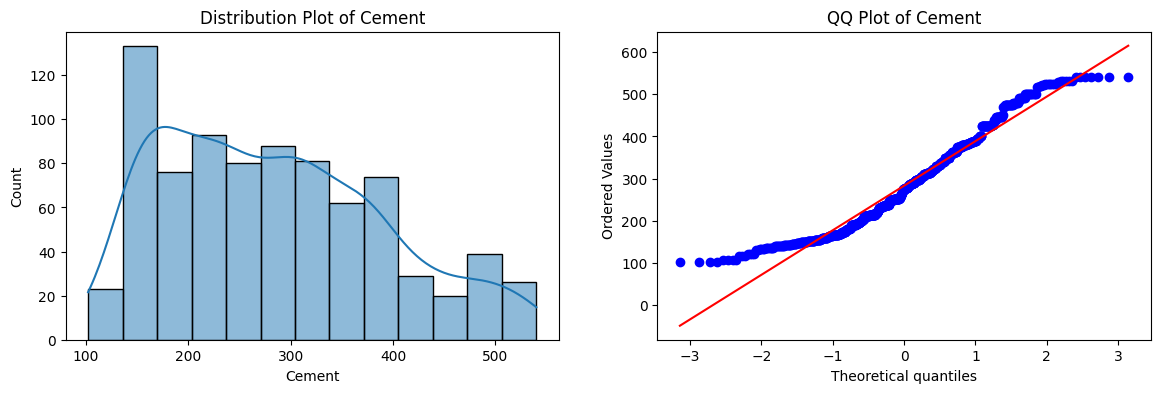

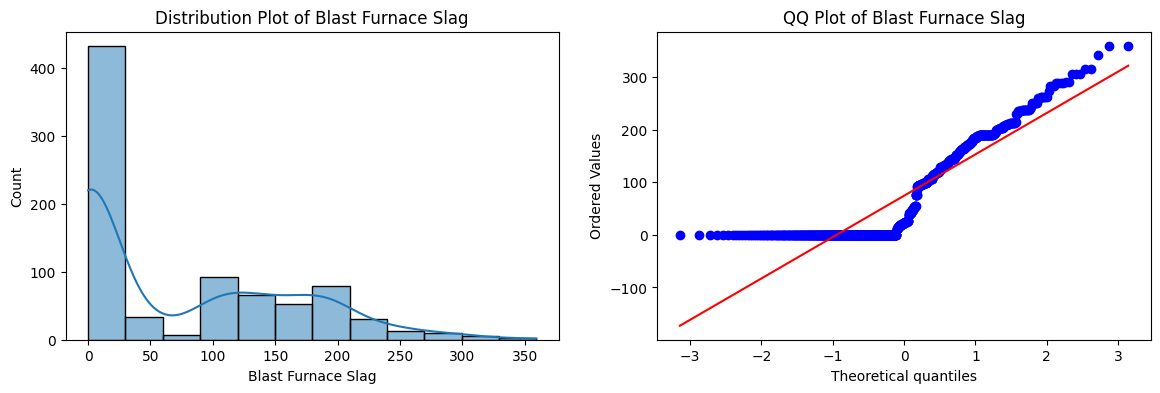

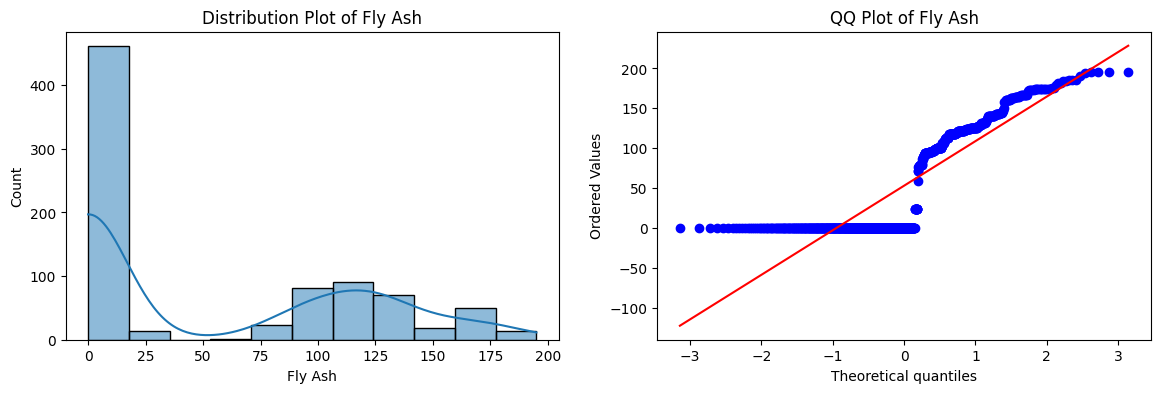

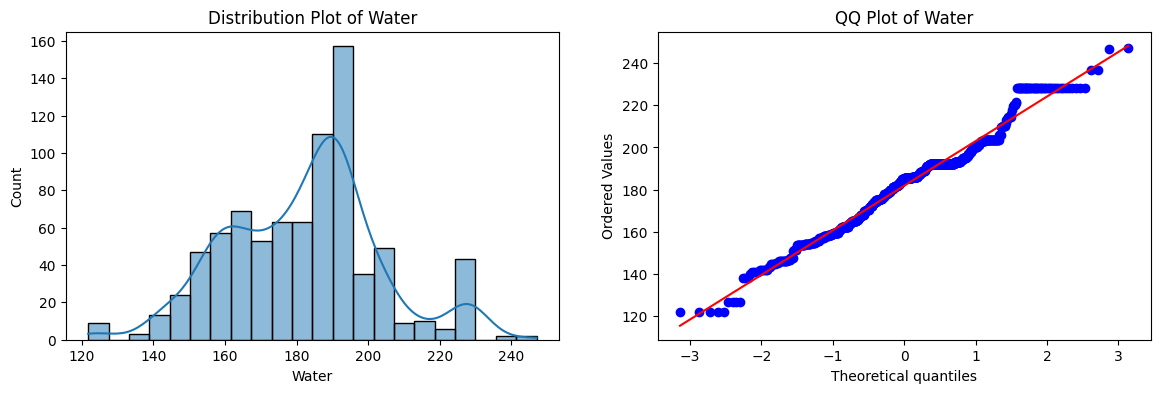

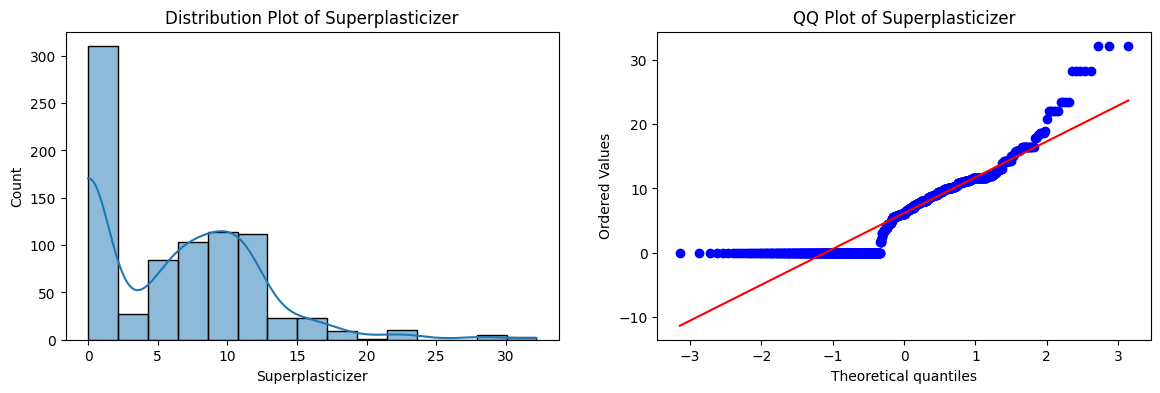

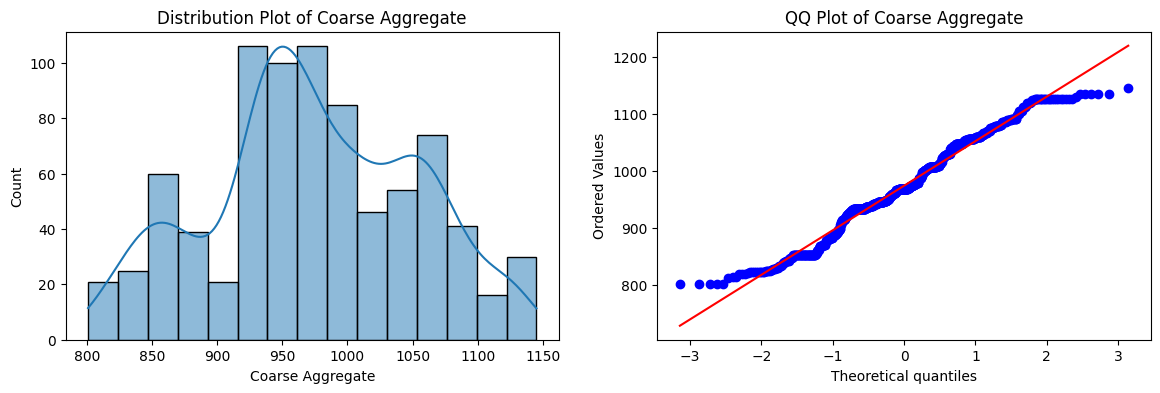

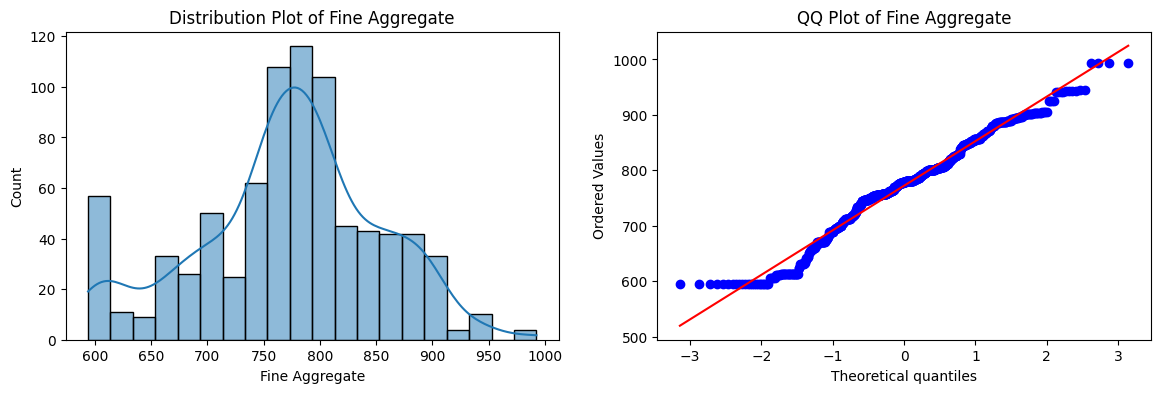

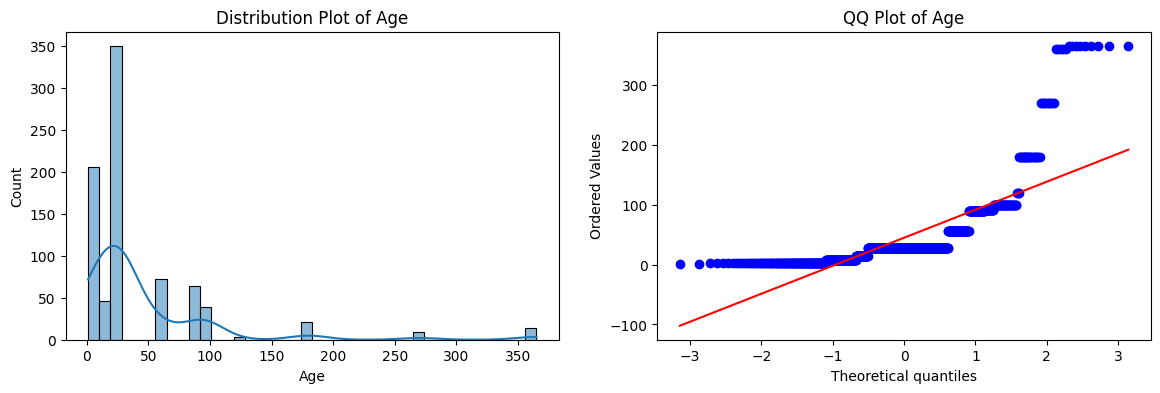

In [32]:
## Plotting the displot without any transformation
# Loop through each column in X_train
for col in X_train.columns:
    
    # Create a figure with width=14 and height=4
    # so both plots can fit side by side clearly
    plt.figure(figsize=(14,4))

    # ---------------- DISTRIBUTION PLOT ----------------
    
    # Create first subplot (1 row, 2 columns, 1st plot)
    plt.subplot(121)

    # histplot is used instead of distplot
    # because distplot is deprecated in newer versions of
    # :contentReference[oaicite:0]{index=0}
    #
    # kde=True adds the smooth density curve
    # to better understand the distribution shape
    sns.histplot(X_train[col], kde=True)

    # Display column name as title
    plt.title(f'Distribution Plot of {col}')

    # ---------------- QQ PLOT ----------------
    
    # Create second subplot (1 row, 2 columns, 2nd plot)
    plt.subplot(122)

    # QQ plot checks whether the data follows
    # a normal distribution or not
    #
    # dist="norm" compares the data with
    # a perfect normal distribution
    stats.probplot(X_train[col], dist="norm", plot=plt)

    # Display title for QQ plot
    plt.title(f'QQ Plot of {col}')

    # Show both plots for the current column
    plt.show()


In [41]:
##Applying Box-Cox transform
pt = PowerTransformer(method = 'box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [42]:

# Applying linear regression on transformed data

lr = LinearRegression()
lr.fit(X_train_transformed,y_train)

y_pred2 = lr.predict(X_test_transformed)

r2_score(y_test,y_pred2)

0.8047825008078886

In [43]:

# Using cross val score

pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+0.0000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.6658537941434354)

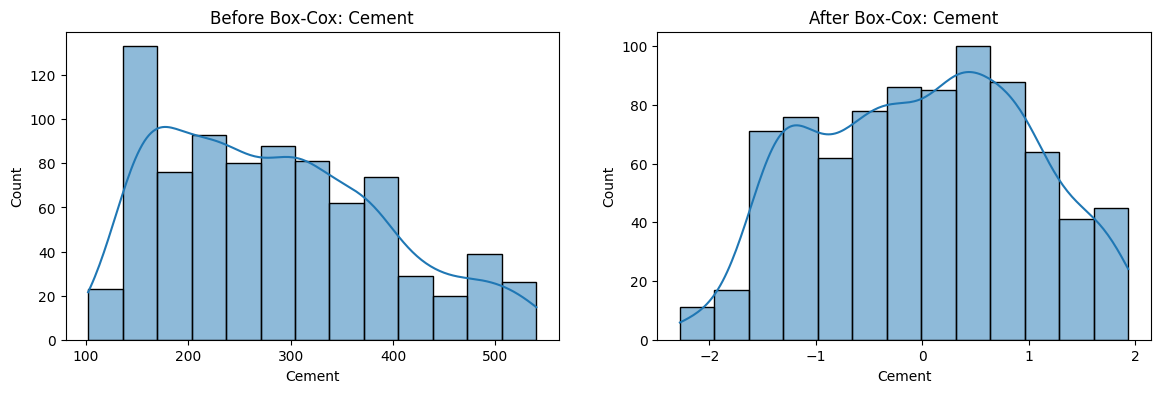

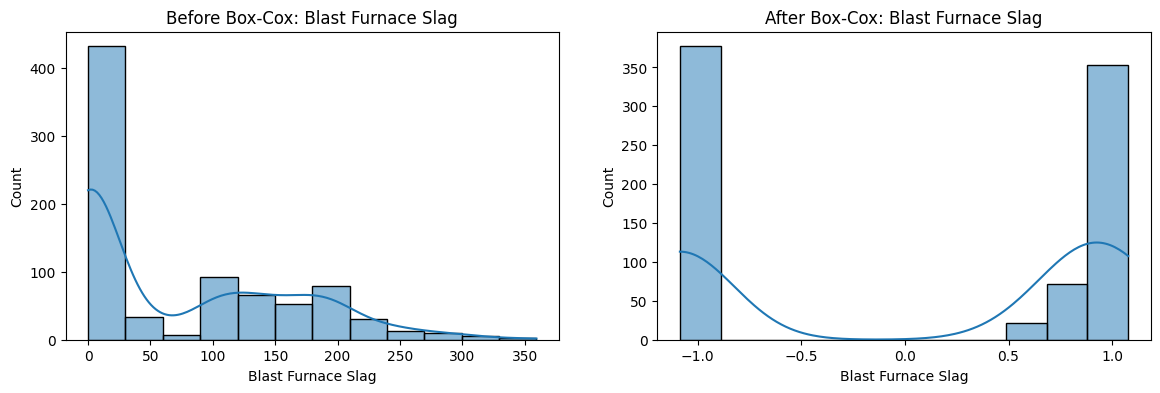

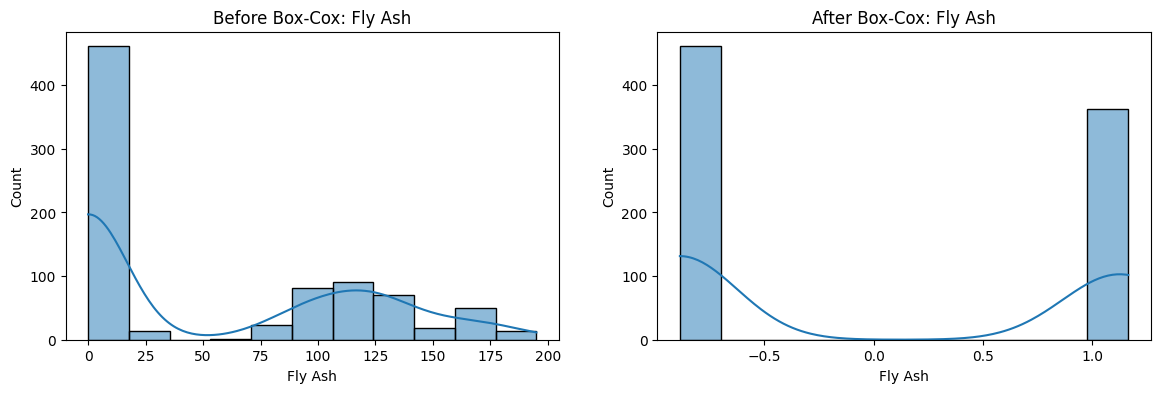

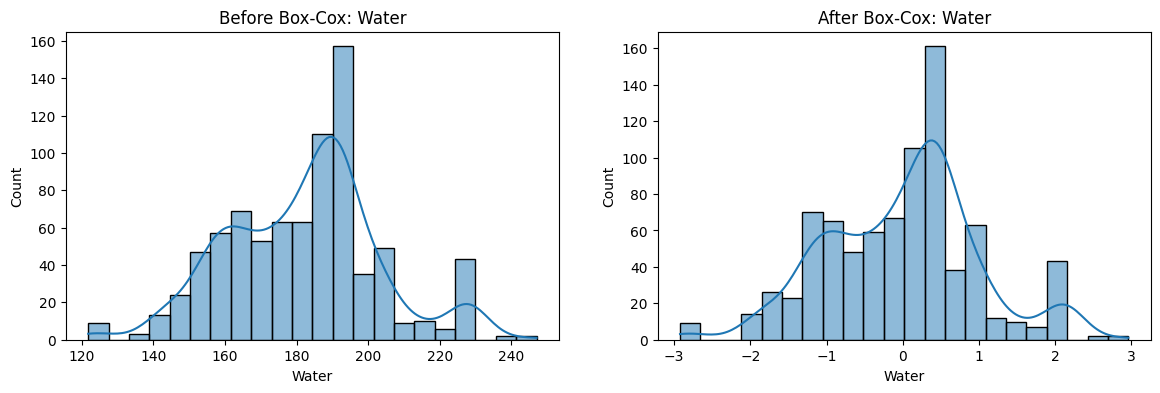

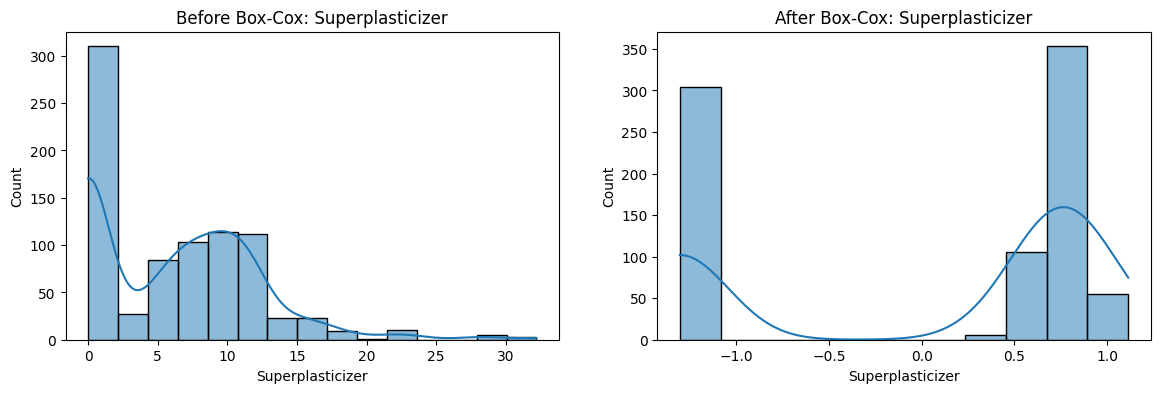

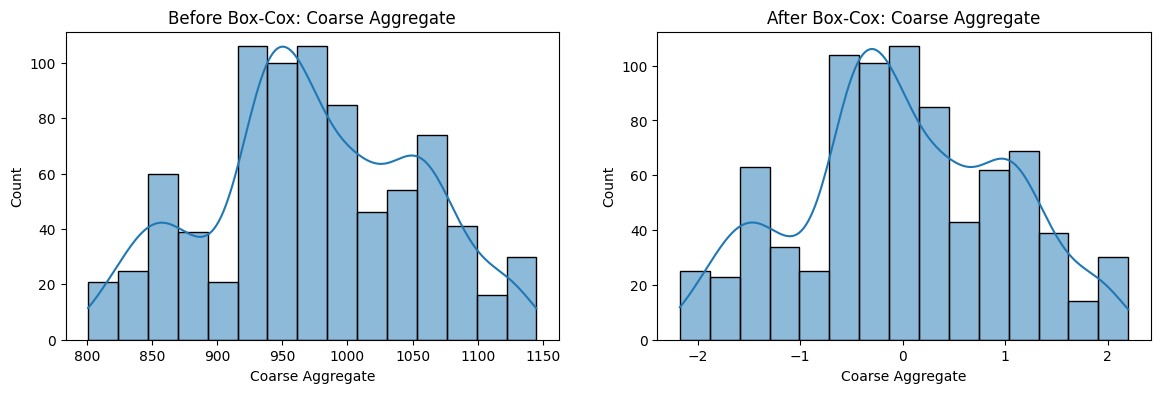

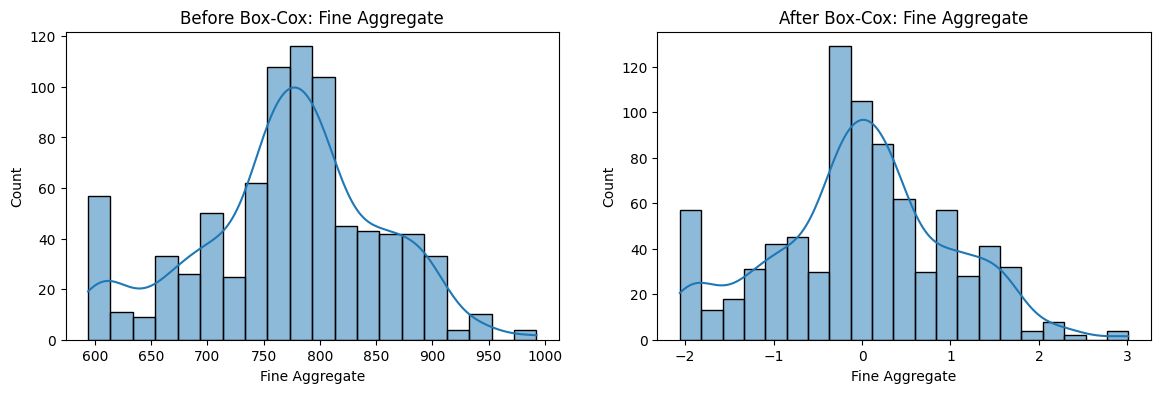

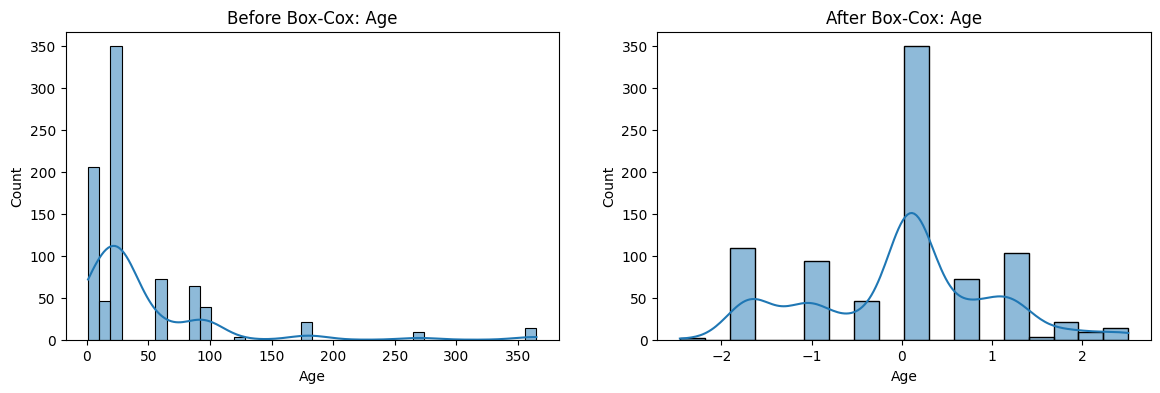

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert transformed array back into DataFrame
# so original column names are preserved
X_train_transformed = pd.DataFrame(
    X_train_transformed,
    columns=X_train.columns
)

# Loop through each column for comparison
for col in X_train_transformed.columns:

    # Create figure for side-by-side comparison
    plt.figure(figsize=(14,4))

    # -------- BEFORE TRANSFORMATION --------
    
    # First subplot
    plt.subplot(121)

    # histplot is used instead of distplot
    # because distplot is deprecated
    #
    # kde=True adds density curve
    sns.histplot(X_train[col], kde=True)

    # Title for original data
    plt.title(f'Before Box-Cox: {col}')

    # -------- AFTER TRANSFORMATION --------
    
    # Second subplot
    plt.subplot(122)

    # Distribution after Box-Cox transformation
    sns.histplot(X_train_transformed[col], kde=True)

    # Title for transformed data
    plt.title(f'After Box-Cox: {col}')

    # Display plots
    plt.show()

In [46]:

# Apply Yeo-Johnson transform

pt1 = PowerTransformer()

X_train_transformed2 = pt1.fit_transform(X_train)
X_test_transformed2 = pt1.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed2,y_train)

y_pred3 = lr.predict(X_test_transformed2)

print(r2_score(y_test,y_pred3))

pd.DataFrame({'cols':X_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

0.8161906511066099


,cols,Yeo_Johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [47]:

# applying cross val score

pt = PowerTransformer()
X_transformed2 = pt.fit_transform(X)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed2,y,scoring='r2'))

np.float64(0.6834625126992436)

In [48]:
X_train_transformed2 = pd.DataFrame(X_train_transformed2,columns=X_train.columns)


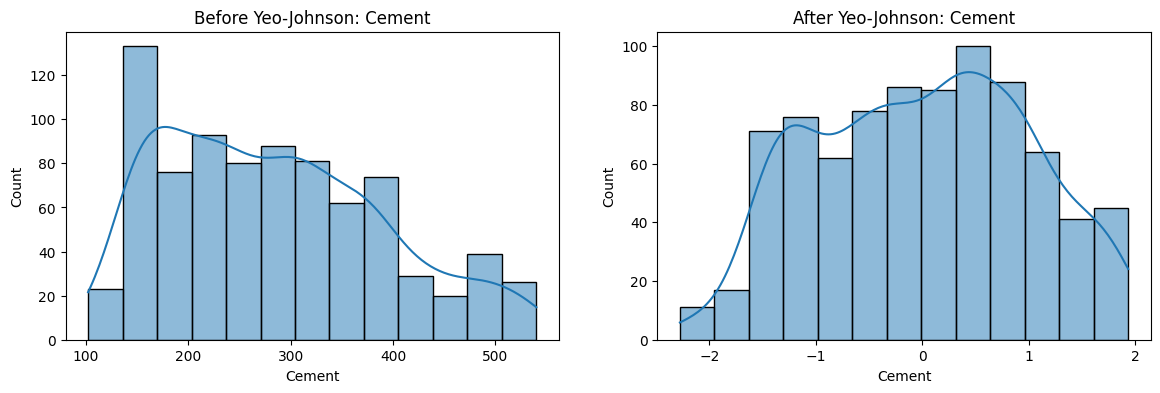

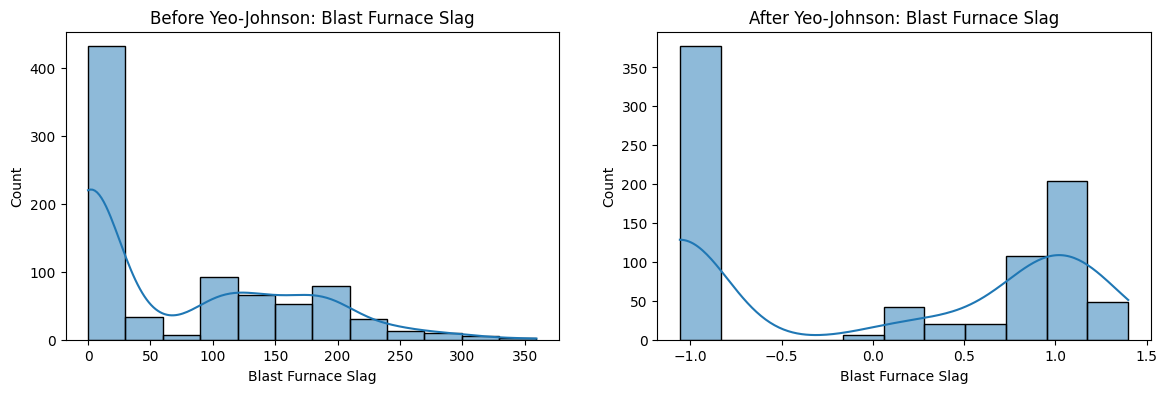

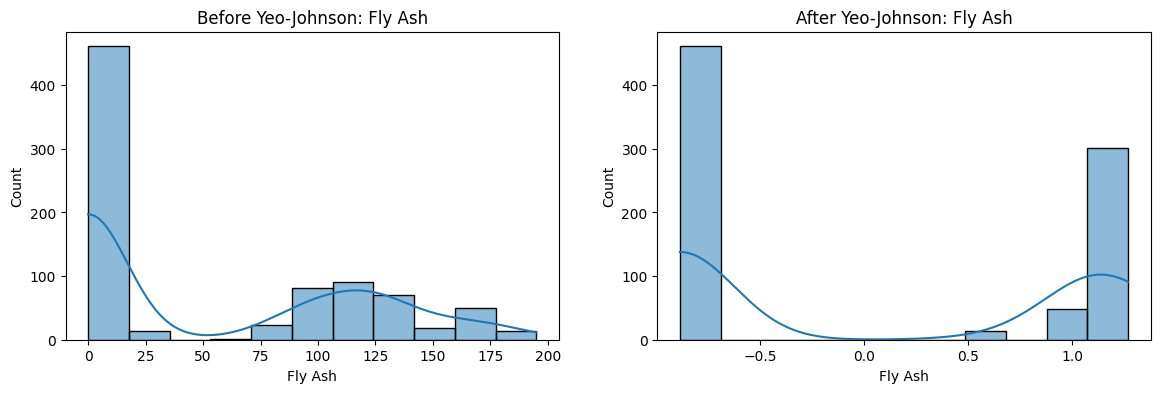

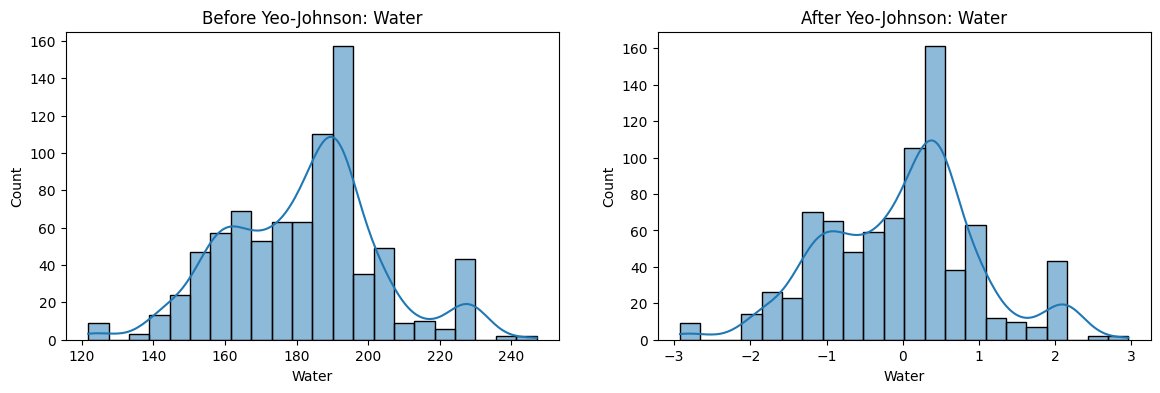

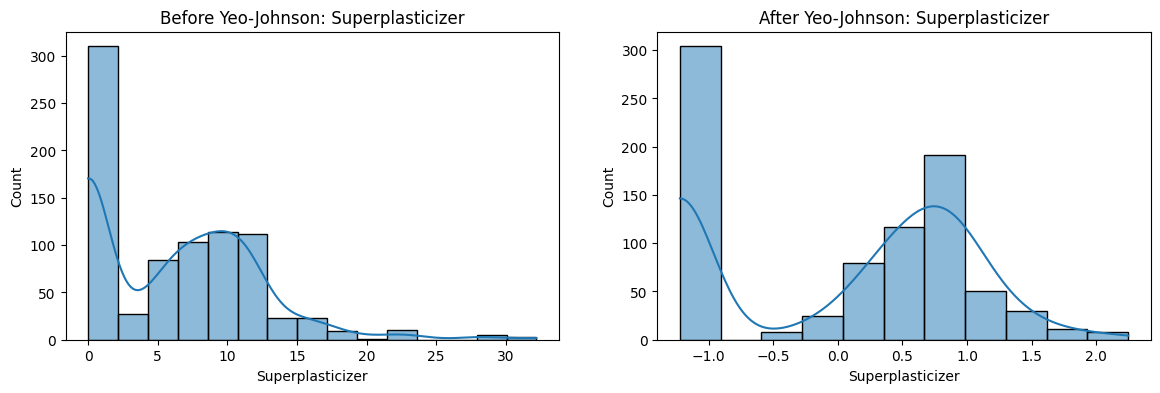

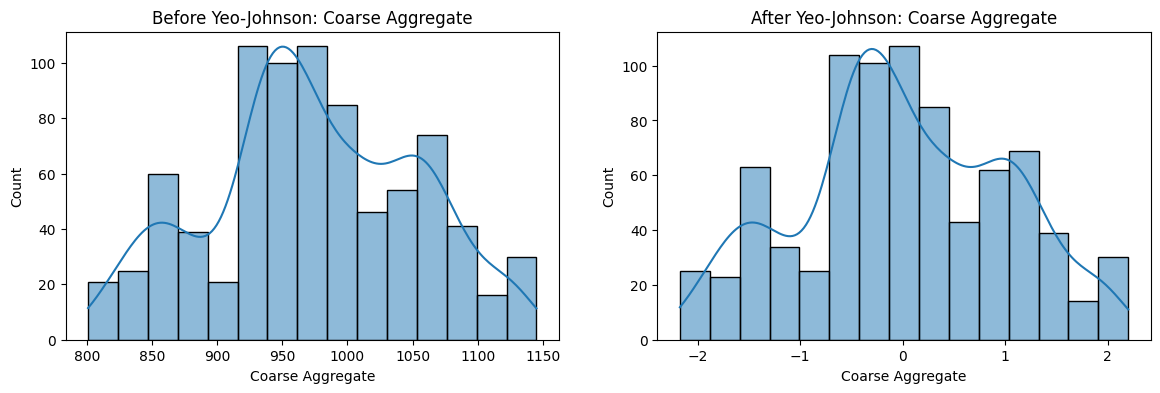

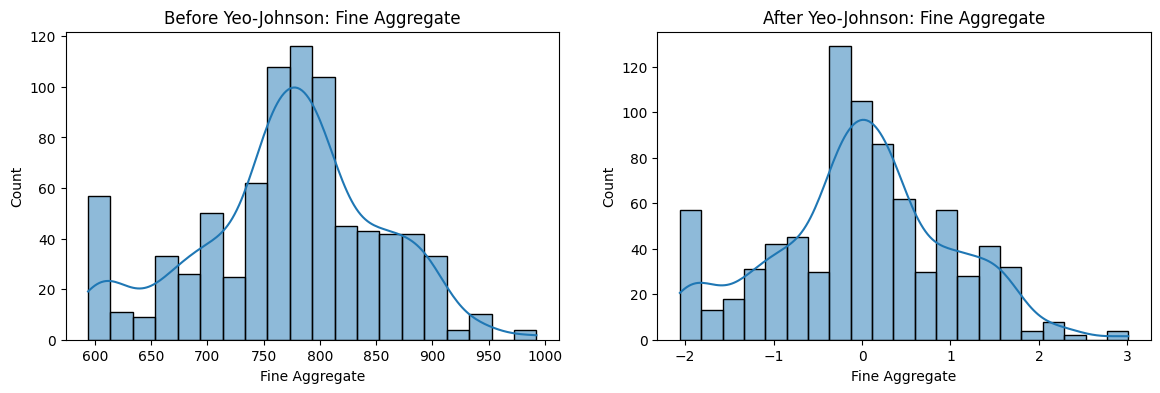

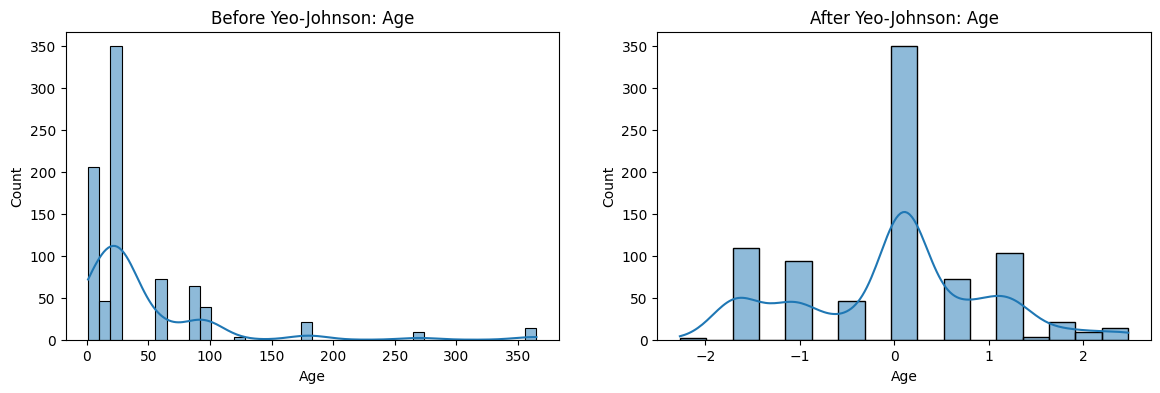

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Before and After Comparison for Yeo-Johnson Transformation

# Loop through each transformed column
for col in X_train_transformed2.columns:

    # Create figure for side-by-side plots
    plt.figure(figsize=(14,4))

    # -------- BEFORE TRANSFORMATION --------
    
    # First subplot
    plt.subplot(121)

    # histplot is used instead of distplot
    # because distplot is deprecated in newer versions of
    # :contentReference[oaicite:0]{index=0}
    #
    # kde=True adds the smooth density curve
    sns.histplot(X_train[col], kde=True)

    # Title for original distribution
    plt.title(f'Before Yeo-Johnson: {col}')

    # -------- AFTER TRANSFORMATION --------
    
    # Second subplot
    plt.subplot(122)

    # Distribution after Yeo-Johnson transformation
    sns.histplot(X_train_transformed2[col], kde=True)

    # Title for transformed distribution
    plt.title(f'After Yeo-Johnson: {col}')

    # Display both plots
    plt.show()

In [50]:
###Difference between Box-Cox and Yeo-Johnson:

#Box-Cox
#Works only on positive values
#Cannot handle 0 or negative numbers
#Yeo-Johnson
#Works with positive, zero, and negative values
#More flexible in real-world datasets

#Both transformations are used to make data more normally distributed and reduce skewness.

In [51]:
# side by side lambdas
pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_,'Yeo_Johnson_lambdas':pt1.lambdas_})


,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,Cement,0.169544,0.174348
1,Blast Furnace Slag,0.016633,0.015715
2,Fly Ash,-0.136480,-0.161447
3,Water,0.808438,0.771307
4,Superplasticizer,0.264160,0.253935
5,Coarse Aggregate,1.129395,1.130050
6,Fine Aggregate,1.830764,1.783100
7,Age,0.001771,0.019885
